In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Data Cleaning

In [7]:
df[df['Unnamed: 2'].isnull() == False] ## Just checking 

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [8]:
df.drop(columns = ['Unnamed: 3','Unnamed: 2','Unnamed: 4'],inplace=True)

In [9]:
df.shape

(5572, 2)

In [10]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.rename(columns={'v1':'Spam_or_Not','v2':'The Message'},inplace=True)

In [12]:
df

,Spam_or_Not,The Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()

In [15]:
 k = le.fit_transform(df['Spam_or_Not'])

In [16]:
df['Target'] = k

In [17]:
df.head()  # 0 means Not spam and 1 means Spam

,Spam_or_Not,The Message,Target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [18]:
df.drop(columns=['Spam_or_Not'])

,The Message,Target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1
5568,Will Ì_ b going to esplanade fr home?,0
5569,"Pity, * was in mood for that. So...any other s...",0
5570,The guy did some bitching but I acted like i'd...,0


In [19]:
df = df[['Target','The Message']]

In [20]:
df

,Target,The Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [21]:
df.duplicated().sum()

np.int64(403)

In [22]:
df.drop_duplicates(keep='first',inplace=True)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_12792\313269892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep='first',inplace=True)


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.head()

,Target,The Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## EDA 

In [25]:
df

,Target,The Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


#### Data is Imbalance

Text(0.5, 1.0, 'Percentage of Spam and Ham in data')

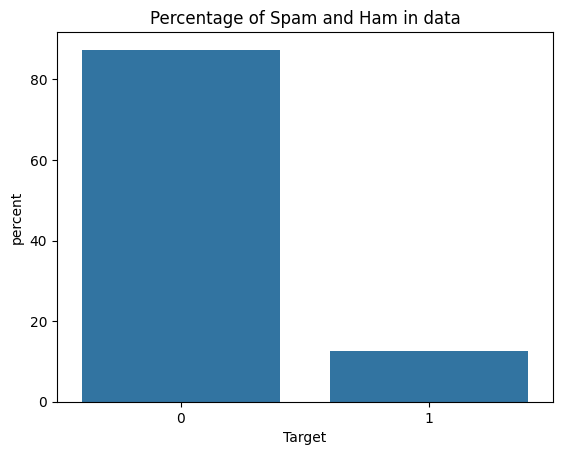

In [28]:
sns.countplot(x = df['Target'],stat='percent')
plt.title('Percentage of Spam and Ham in data')

In [29]:
pip install nltk 


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 5.0 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.6 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ---------

In [30]:
import nltk

In [41]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Harshgupta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [37]:
df['Number of Characters'] = df['The Message'].apply(len)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_12792\2191811808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Number of Characters'] = df['The Message'].apply(len)


In [51]:
df['Count of Words'] = df['The Message'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_12792\1203275940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Count of Words'] = df['The Message'].apply(lambda x:len(nltk.word_tokenize(x)))


In [52]:
df

,Target,The Message,Number of Characters,Count of Words,Count of Sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [53]:
df['Count of Sentence'] = df['The Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_12792\1652612812.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Count of Sentence'] = df['The Message'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [56]:
df[['Number of Characters','Count of Words','Count of Sentence']].describe()

,Number of Characters,Count of Words,Count of Sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


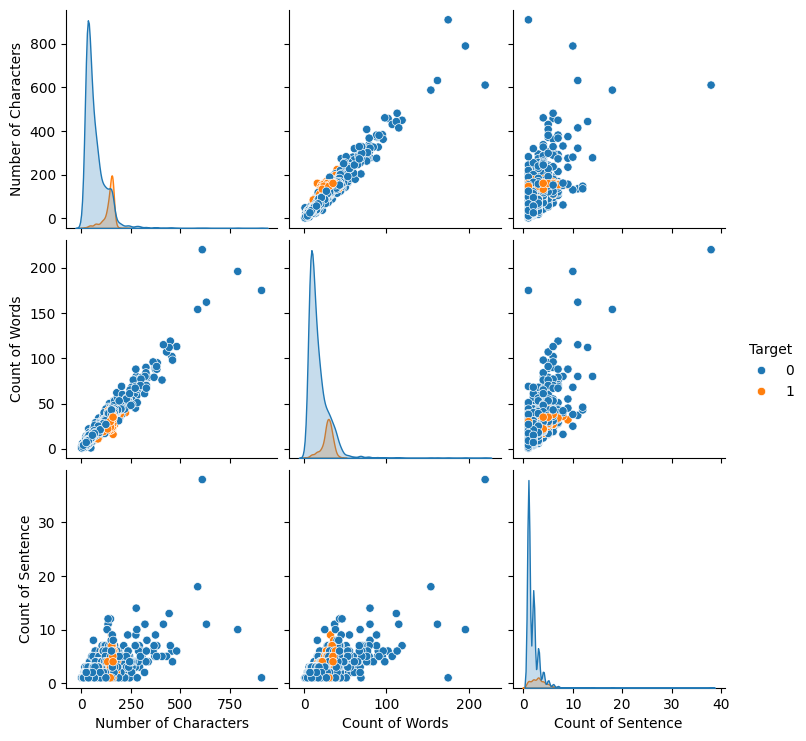

In [73]:
sns.pairplot(
    df[['Number of Characters', 'Count of Words', 'Count of Sentence', 'Target']],
    hue='Target'
)

In [80]:
# Ham
df[df['Target']==0][['Number of Characters', 'Count of Words', 'Count of Sentence']].describe()

,Number of Characters,Count of Words,Count of Sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [81]:
# Spam
df[df['Target']==1][['Number of Characters', 'Count of Words', 'Count of Sentence']].describe()

,Number of Characters,Count of Words,Count of Sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [83]:
df.corr(numeric_only=True)

,Target,Number of Characters,Count of Words,Count of Sentence
Target,1.000000,0.384717,0.262720,0.263939
Number of Characters,0.384717,1.000000,0.965686,0.624139
Count of Words,0.262720,0.965686,1.000000,0.679767
Count of Sentence,0.263939,0.624139,0.679767,1.000000


<Axes: >

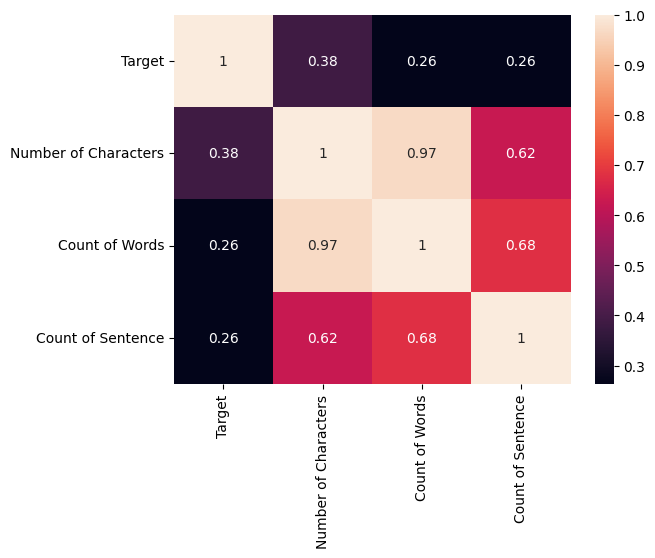

In [84]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Processing
- lower case
- Tokenization
- Removing special character
- Removing stop words and punctuation
- Stemming

In [103]:
from nltk.corpus import stopwords 

In [120]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Dancing')

'danc'

In [127]:
def transform_text(data):
    data = data.lower()
    data = nltk.word_tokenize(data)
    lst = []
    for i in data:
        if i.isalnum():
            lst.append(i)
    data = lst[:]
    lst.clear()
    for i in data:
        if i not in stopwords.words('english') and i not in string.punctuation:
            lst.append(i)

    data = lst[:]
    lst.clear()
    for i in data:
        lst.append(ps.stem(i))
        
    return " ".join(lst)

In [128]:
transform_text('Hello Harsh How are%%% you??')

'hello harsh'

In [129]:
transform_text('Heyi how you doing that a very great start !')

'heyi great start'

In [131]:
transform_text('I loved soo much Learning ML from Campusx ')

'love soo much learn ml campusx'

In [141]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [126]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [136]:
df['The Message'].sample()

5100    Aight, call me once you're close
Name: The Message, dtype: object

In [143]:
df['Transformed Text'] = df['The Message'].apply(transform_text)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_12792\371693635.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Transformed Text'] = df['The Message'].apply(transform_text)


In [144]:
df

,Target,The Message,Number of Characters,Count of Words,Count of Sentence,Transformed Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [145]:
from wordcloud import WordCloud

In [151]:
wc = WordCloud(background_color='white',include_numbers=True, min_font_size=9,width=500,height=300)

In [152]:
spam_wc = wc.generate(df[df['Target']==1]['Transformed Text'].str.cat(sep=' '))

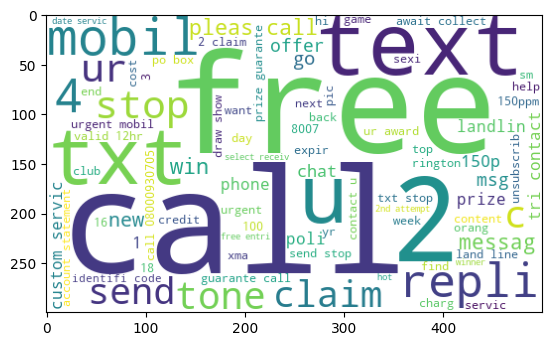

In [153]:
plt.imshow(spam_wc)

In [156]:
ham_wc = wc.generate(df[df['Target']==0]['Transformed Text'].str.cat(sep=' '))

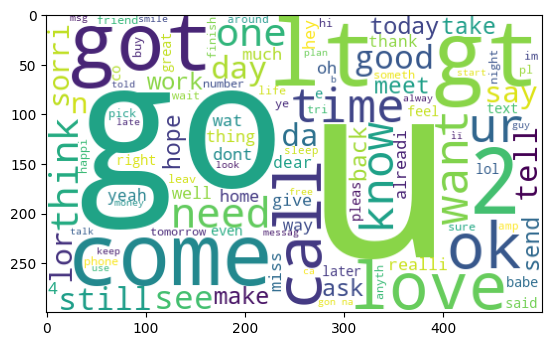

In [157]:
plt.imshow(ham_wc)

In [158]:
df

,Target,The Message,Number of Characters,Count of Words,Count of Sentence,Transformed Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [195]:
spam_corpus = []
for msg in df[df['Target']==1]['Transformed Text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [199]:
len(spam_corpus)

9942

In [184]:
from collections import Counter
top_30_spam =pd.DataFrame(Counter(spam_corpus).most_common(30))

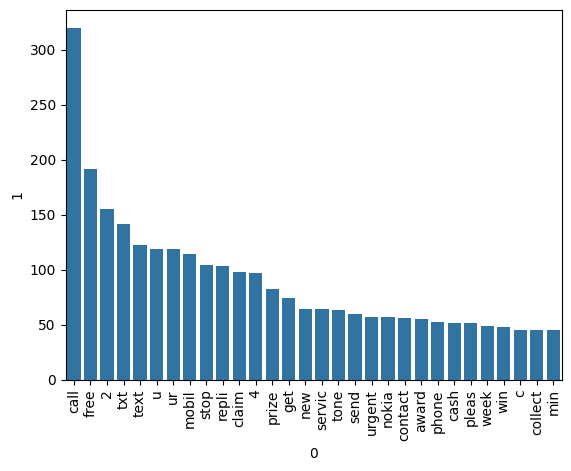

In [189]:
sns.barplot(x = top_30_spam[0],y = top_30_spam[1])
plt.xticks(rotation=90)
plt.show()

In [197]:
ham_corpus = []
for msg in df[df['Target']==0]['Transformed Text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [198]:
len(ham_corpus)

35423

In [202]:
top_30_ham =pd.DataFrame(Counter(ham_corpus).most_common(30))

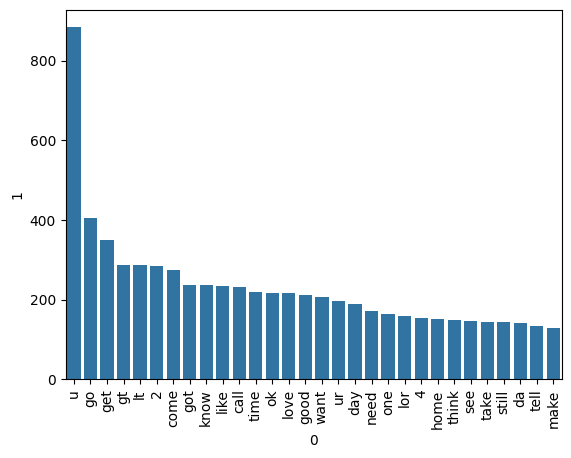

In [203]:
sns.barplot(x = top_30_ham[0],y = top_30_ham[1])
plt.xticks(rotation=90)
plt.show()

In [249]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer  # Text to Vectoer(Number) mai convert krne wali technique he

In [251]:
cv = CountVectorizer() # thik thak aya perfromance

In [252]:
tfid = TfidfVectorizer() # better aya

In [237]:
X = tfid.fit_transform(df['Transformed Text']).toarray()

In [238]:
X.shape

(5169, 6715)

In [239]:
y = df['Target']

In [240]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [241]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [248]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB # Why Naive Bayes because Textual data pe best performance deta hai isliye uske sath start kiya

In [243]:
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()

In [244]:
gnb.fit(X_train,y_train)
y_pred = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.8762088974854932
0.5231481481481481
[[793 103]
 [ 25 113]]


In [245]:
bnb.fit(X_train,y_train)
y_pred1 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

0.9700193423597679
0.9734513274336283
[[893   3]
 [ 28 110]]


In [246]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

0.9593810444874274
1.0
[[896   0]
 [ 42  96]]


In [247]:
# Abhi tk ke liye ye apna TfidVector wala with MNB accha perform kr rhe hai

In [253]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [254]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.0 MB/s eta 0:00:20
    --------------------------------------- 2.4/101.7 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 3.9/101.7 MB 6.5 MB/s eta 0:00:15
   - -------------------------------------- 5.0/101.7 MB 6.3 MB/s eta 0:00:16
   -- ------------------------------------- 5.5/101.7 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 6.3/101.7 MB 5.0 MB/s eta 0:00:20
   -- ------------------------------------- 7.6/101.7 MB 5.0 MB/s eta 0:00:19
   --- ------------------------------------ 8.7/101.7 MB 5.0 MB/s eta 0:00:19
   --- ------------------------------------ 9.2/101.7 MB 4.7 MB/s eta 0:00:20
   ---- ----------------------------------- 10.2/101.7 MB 4.8 MB/s eta 0:00:19
   ---- ----------------------------------- 12.3/101.7 MB 5.2 MB/s eta 0:00:18
   ----- ---------------------------------- 15.2/101.7 MB 5.9 MB/s e